# 02 — Feature Engineering

Time features, macro indicators, geospatial features, alert analysis.


In [1]:
# ── Imports + project root ─────────────────────────────────────────────────
import os, sys, re, io, pathlib, warnings, datetime, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import linregress, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
warnings.filterwarnings('ignore')

# ── Project root ───────────────────────────────────────────────────────────
_CWD = pathlib.Path(os.getcwd()).resolve()
_ROOT = _CWD
for _ in range(6):
    if (_ROOT / 'requirements.txt').exists() and (_ROOT / 'src').exists():
        break
    _ROOT = _ROOT.parent
else:
    raise RuntimeError(f'thesis_package root not found. CWD={_CWD}')

os.chdir(_ROOT)
sys.path.insert(0, str(_ROOT))
_DATA_DIR = _ROOT / 'notebooks' / 'notebooks_data'
_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── src imports ───────────────────────────────────────────────────────────────
from src.data import drop_gaps, split_mask
from src.config import SEGMENT_KEYS
from src.macro import build_macro_df, load_monthly_alerts, add_macro_features, add_alert_features
from src.geo import (add_geo_features, add_knn_price_feature,
                     add_district_month_median, add_post_external_interactions)
from src.features import run_feature_engineering

# ── Global constants ──────────────────────────────────────────────────────
WAR_START    = pd.Timestamp('2022-02-24')
TRAIN_END    = pd.Timestamp('2025-04-30')
TRAIN_CUTOFF = TRAIN_END
VAL_START    = pd.Timestamp('2025-06-01')
VAL_END      = pd.Timestamp('2025-08-31')
TEST_START   = pd.Timestamp('2025-10-01')
GAP1_START   = pd.Timestamp('2025-05-01')
GAP1_END     = pd.Timestamp('2025-05-31')
GAP2_START   = pd.Timestamp('2025-09-01')
GAP2_END     = pd.Timestamp('2025-09-30')
RANDOM_STATE = 42

print(f'✅ Root        : {_ROOT}')
print(f'✅ Data dir    : {_DATA_DIR}')
print(f'✅ WAR_START   = {WAR_START.date()}')
print(f'✅ TRAIN_END   = {TRAIN_END.date()}')
print(f'✅ TEST_START  = {TEST_START.date()}')


✅ Root        : /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package
✅ Data dir    : /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package/notebooks/notebooks_data
✅ WAR_START   = 2022-02-24
✅ TRAIN_END   = 2025-04-30
✅ TEST_START  = 2025-10-01


In [2]:
# ── Load clean_segments from notebook 01 ─────────────────────────────────
import pickle
_pkl = _DATA_DIR / 'clean_segments.pkl'
if not _pkl.exists():
    raise FileNotFoundError(
        f'File not found: {_pkl}\n'
        '→ First run 01_eda_data_quality.ipynb (Run All)'
    )
with open(_pkl, 'rb') as f:
    _clean = pickle.load(f)
df_rent_lviv_clean = _clean[('Львів','Оренда')]
df_rent_kyiv_clean = _clean[('Київ', 'Оренда')]
df_sale_lviv_clean = _clean[('Львів','Продаж')]
df_sale_kyiv_clean = _clean[('Київ', 'Продаж')]
print('✅ clean_segments loaded')
for k,v in _clean.items(): print(f'  {k}: {len(v):,} rows')


✅ clean_segments loaded
  ('Львів', 'Оренда'): 126,946 rows
  ('Київ', 'Оренда'): 193,642 rows
  ('Львів', 'Продаж'): 142,972 rows
  ('Київ', 'Продаж'): 501,172 rows


## 7. Feature Engineering

We transform raw columns into meaningful features for the ML model.
Each feature group has a theoretical justification within the **hedonic pricing model** (Rosen, 1974).

### Feature groups:
| Group | Features | Justification |
|-------|----------|---------------|
| Time | year, month, quarter, month_sin/cos, is_wartime | Seasonality + wartime context |
| Floor | floor_ratio, is_first/last_floor | Non-linear floor effect |
| Area | living_ratio, kitchen_ratio, area_per_room | Layout quality |
| Building | building_age, building_era, is_new_building | Architectural era |
| Autonomy | autonomy_score, has_power_autonomy | **Wartime-specific feature** |
| Amenities | amenity_score, amenity_count | Standard hedonic attributes |
| Price | log_price_m2_usd, price_zscore, price_tier | Target + normalisation |
| Interactions | autonomy_x_wartime | Effect of autonomy during war |


In [3]:
def add_time_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['is_wartime'] = (df['date'] >= WAR_START).astype(int)
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

def add_floor_features(df):
    df = df.copy()
    df['floor'] = pd.to_numeric(df.get('floor'), errors='coerce')
    df['floor_count'] = pd.to_numeric(df.get('floor_count'), errors='coerce')
    df['floor_ratio'] = df['floor'] / (df['floor_count'] + 1e-9)
    df['is_first_floor'] = (df['floor'] == 1).astype(int)
    df['is_last_floor'] = ((df['floor'] == df['floor_count']) & df['floor'].notna()).astype(int)
    return df

def add_area_features(df):
    df = df.copy()
    df['area_total'] = pd.to_numeric(df.get('area_total'), errors='coerce')
    df['area_living'] = pd.to_numeric(df.get('area_living'), errors='coerce')
    df['area_kitchen'] = pd.to_numeric(df.get('area_kitchen'), errors='coerce')
    df['living_ratio'] = df['area_living'] / (df['area_total'] + 1e-9)
    df['kitchen_ratio'] = df['area_kitchen'] / (df['area_total'] + 1e-9)
    df['area_per_room'] = df['area_total'] / (pd.to_numeric(df.get('room_count'), errors='coerce') + 1e-9)
    return df

def add_building_features(df):
    df = df.copy()
    df['built_year'] = pd.to_numeric(df.get('built_year'), errors='coerce')
    df['building_age'] = (df['year'] - df['built_year']).clip(0, 120)
    def classify_era(y):
        if pd.isna(y):  return 'Unknown'
        if y < 1960:    return 'Stalin-era (<1960)'
        if y < 1976:    return 'Khrushchyovka (1960-1975)'
        if y < 1992:    return 'Brezhnev-era (1976-1991)'
        if y < 2011:    return 'Post-Soviet (1992-2010)'
        return 'New-build (after 2010)'
    df['building_era']    = df['built_year'].apply(classify_era)
    df['is_new_building'] = (df['built_year'] >= 2010).astype(int)
    return df

def add_autonomy_features(df):
    df = df.copy()
    autonomy_cols = ['autonomy_power', 'autonomy_heat', 'autonomy_water', 'autonomy_net', 'autonomy_lift']
    existing = [c for c in autonomy_cols if c in df.columns]
    if existing:
        def _to_yes_binary(s):
            if s.dtype == object or str(s.dtype).startswith('category'):
                mapped = (
                    s.astype(str).str.strip().str.lower()
                    .map({'yes': 1, 'true': 1, '1': 1, '1.0': 1,
                          'no': 0, 'false': 0, '0': 0, '0.0': 0, 'nan': np.nan})
                )
                return pd.to_numeric(mapped, errors='coerce')
            return pd.to_numeric(s, errors='coerce')

        autonomy_bin = pd.DataFrame({c: _to_yes_binary(df[c]) for c in existing}, index=df.index)
        df['autonomy_score'] = autonomy_bin.fillna(0).sum(axis=1)
        df['has_any_autonomy'] = (df['autonomy_score'] > 0).astype(int)
    return df

def add_amenity_features(df):
    df = df.copy()
    amenity_weights = {'has_furniture': 1.0, 'has_balcony': 0.8, 'has_parking': 1.2, 'has_gas': 0.5}
    existing = {k: v for k, v in amenity_weights.items() if k in df.columns}
    if existing:
        df['amenity_score'] = sum(pd.to_numeric(df[c], errors='coerce').fillna(0) * w
                                  for c, w in existing.items())
        df['amenity_count'] = sum(pd.to_numeric(df[c], errors='coerce').fillna(0)
                                  for c in existing)
    return df

def add_price_features(df, contract_type, train_cutoff='2024-12-31'):
    """Log-transform price columns. price_zscore_room uses train statistics only."""
    df = df.copy()
    for col in ['price_usd', 'price_uah', 'price_m2_usd', 'price_m2_uah']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(pd.to_numeric(df[col], errors='coerce'))

    price_col = 'price_m2_usd' if contract_type == 'Продаж' else 'price_uah'
    if price_col in df.columns and 'room_count' in df.columns and 'date' in df.columns:
        df['room_count'] = pd.to_numeric(df['room_count'], errors='coerce')
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        price_num = pd.to_numeric(df[price_col], errors='coerce')
        train_mask = df['date'] <= pd.Timestamp(train_cutoff)
        room_stats = (
            pd.DataFrame({'room_count': df.loc[train_mask, 'room_count'], 'price': price_num.loc[train_mask]})
            .dropna()
            .groupby('room_count')['price']
            .agg(['median', 'std'])
            .rename(columns={'median': 'room_median', 'std': 'room_std'})
        )
        df = df.merge(room_stats, how='left', left_on='room_count', right_index=True)
        df['price_zscore_room'] = (price_num - df['room_median']) / (df['room_std'].fillna(0) + 1e-9)
        df.drop(columns=['room_median', 'room_std'], inplace=True, errors='ignore')
    return df

def add_interaction_features(df):
    """H1-relevant interactions: internal × external (war/macro/alerts).
    All derivations are deterministic, no test leakage.
    """
    df = df.copy()
    if 'date' in df.columns:
        df['is_wartime'] = (pd.to_datetime(df['date'], errors='coerce') >= WAR_START).astype(int)

    if 'autonomy_score' in df.columns and 'alert_count_month' in df.columns:
        df['autonomy_x_alerts'] = (
            pd.to_numeric(df['autonomy_score'], errors='coerce').fillna(0) *
            pd.to_numeric(df['alert_count_month'], errors='coerce').fillna(0)
        )

    if 'autonomy_score' in df.columns and 'is_wartime' in df.columns:
        df['autonomy_x_wartime'] = (
            pd.to_numeric(df['autonomy_score'], errors='coerce').fillna(0) * df['is_wartime']
        )

    if 'is_new_building' in df.columns and 'usd_uah' in df.columns:
        df['newbuild_x_usd'] = (
            pd.to_numeric(df['is_new_building'], errors='coerce').fillna(0) *
            pd.to_numeric(df['usd_uah'], errors='coerce')
        )

    if 'dist_to_shelter_km' in df.columns and 'alert_count_month' in df.columns:
        df['shelter_x_alerts'] = (
            pd.to_numeric(df['dist_to_shelter_km'], errors='coerce').fillna(0) *
            pd.to_numeric(df['alert_count_month'], errors='coerce').fillna(0)
        )

    if 'days_since_war' in df.columns and 'usd_uah' in df.columns:
        dsw = pd.to_numeric(df['days_since_war'], errors='coerce').clip(lower=1)
        usd = pd.to_numeric(df['usd_uah'], errors='coerce').clip(lower=1)
        df['log_days_x_log_usd'] = np.log1p(dsw) * np.log1p(usd)

    if 'building_era' in df.columns and 'dist_to_center_km' in df.columns:
        era_order = {
            'Stalin-era (<1960)': 4,
            'Khrushchyovka (1960-1975)': 2,
            'Brezhnev-era (1976-1991)': 3,
            'Post-Soviet (1992-2010)': 5,
            'New-build (after 2010)': 6,
            'Unknown': 0,
        }
        era_ord = df['building_era'].map(era_order).fillna(0)
        df['era_ord_x_center'] = era_ord * pd.to_numeric(df['dist_to_center_km'], errors='coerce').fillna(0)

    if 'area_total' in df.columns and 'room_count' in df.columns:
        at = pd.to_numeric(df['area_total'], errors='coerce')
        rc = pd.to_numeric(df['room_count'], errors='coerce')
        df['area_per_room_strict'] = at / (rc + 1e-9)

    return df

def run_feature_engineering(df, contract_type, label=''):
    n_before = len(df.columns)
    df = add_time_features(df)
    df = add_floor_features(df)
    df = add_area_features(df)
    df = add_building_features(df)
    df = add_autonomy_features(df)
    df = add_amenity_features(df)
    df = add_price_features(df, contract_type)
    df = add_interaction_features(df)
    added = len(df.columns) - n_before
    print(f"  [{label}] +{added} features → total {len(df.columns)} cols | rows: {len(df):,}")
    return df


## 7.2 Macroeconomic indicators

We add three external sources and join them to the dataset by month:

| File | Extracted | New features |
|---|---|---|
| `Exchange_r (4).xls` | Official USD/UAH rate (NBU) | `usd_uah` |
| `DF_PRICE_CHANGE_CONSTRUCTION` | Construction price index (total + residential), % vs December of previous year | `construction_idx_total`, `construction_idx_residential` |
| `DF_PRICE_CHANGE_CONSUMER_GOODS` | Average price of bread+milk+eggs → normalised index (Jan 2023=100) | `food_price_idx` |


In [4]:
# ─────────────────────────────────────────────────────────────
# MACRO: NBU key policy rate
# Source: https://bank.gov.ua/ua/monetary/archive-rish
#
# Logic: rate is in force from a given date until the next change
# → for each month we take the last effective value
# ─────────────────────────────────────────────────────────────

# Effective date → rate (% per year)
NBU_RATE_CHANGES = [
    # 2023
    ('2023-01-27', 25.0),
    ('2023-03-17', 25.0),
    ('2023-04-28', 25.0),
    ('2023-06-16', 25.0),
    ('2023-07-28', 22.0),
    ('2023-09-15', 20.0),
    ('2023-10-27', 16.0),
    ('2023-12-15', 15.0),
    # 2024
    ('2024-01-26', 15.0),
    ('2024-03-15', 14.5),
    ('2024-04-26', 13.5),
    ('2024-06-14', 13.0),
    ('2024-07-26', 13.0),
    ('2024-09-20', 13.0),
    ('2024-11-01', 13.0),
    ('2024-12-13', 13.5),
    # 2025
    ('2025-01-24', 14.5),
    ('2025-03-07', 15.5),
    ('2025-04-18', 15.5),
    ('2025-06-06', 15.5),
    ('2025-07-25', 15.5),
    ('2025-09-12', 15.5),
    ('2025-10-24', 15.5),
    ('2025-12-12', 15.5),
    # 2026
    ('2026-01-30', 15.0),
    ('2026-03-20', 15.0),
]

def load_nbu_rate(changes=NBU_RATE_CHANGES, freq_start='2023-01-01', freq_end='2026-12-01'):
    """
    Build monthly NBU policy rate series.
    For each month — the rate effective at end of month.
    """
    df_changes = pd.DataFrame(changes, columns=['date', 'nbu_rate'])
    df_changes['date'] = pd.to_datetime(df_changes['date'])
    df_changes = df_changes.sort_values('date').reset_index(drop=True)

    # Generate monthly scale
    months = pd.date_range(start=freq_start, end=freq_end, freq='MS')
    df_monthly = pd.DataFrame({'year_month': months})

    # For each month find the last rate change ≤ end-of-month
    # (end-of-month = start of next - 1 day)
    df_monthly['_month_end'] = df_monthly['year_month'] + pd.offsets.MonthEnd(0)

    rates = []
    for _, row in df_monthly.iterrows():
        applicable = df_changes[df_changes['date'] <= row['_month_end']]
        rate = applicable.iloc[-1]['nbu_rate'] if len(applicable) > 0 else np.nan
        rates.append(rate)

    df_monthly['nbu_rate'] = rates
    df_monthly = df_monthly.drop(columns=['_month_end'])

    print(f"✅ NBU rate: {df_monthly['nbu_rate'].notna().sum()} months")
    print(f"   Range:  {df_monthly['year_month'].min().date()} → {df_monthly['year_month'].max().date()}")
    print(f"   Min: {df_monthly['nbu_rate'].min()}%  |  Max: {df_monthly['nbu_rate'].max()}%")
    print(f"\n   Last 6 months:")
    print(df_monthly.tail(6).to_string(index=False))
    return df_monthly


df_nbu = load_nbu_rate()


✅ Облікова ставка НБУ: 48 місяців
   Діапазон: 2023-01-01 → 2026-12-01
   Мін: 13.0%  |  Макс: 25.0%

   Останні 6 місяців:
year_month  nbu_rate
2026-07-01      15.0
2026-08-01      15.0
2026-09-01      15.0
2026-10-01      15.0
2026-11-01      15.0
2026-12-01      15.0


In [5]:
warnings.filterwarnings('ignore', category=UserWarning)

# Macro files live in thesis_package/data/
_DATA_FILES = _ROOT / 'data'

FILE_EXCHANGE = str(_DATA_FILES / 'Exchange_r (4).xls')
FILE_CONSTR   = str(next(_DATA_FILES.glob('*CONSTRUCTION*.xlsx')))
FILE_CONSUMER = str(next(_DATA_FILES.glob('*CONSUMER_GOODS*.xlsx')))


def load_exchange_rates(path):
    xl = pd.ExcelFile(path)
    records = []
    for sheet in xl.sheet_names:
        df_xl = pd.read_excel(path, sheet_name=sheet, header=None)
        yr_row_idx = None
        for i in range(6):
            yr_vals = [v for v in df_xl.iloc[i]
                       if isinstance(v, (int, float)) and 1990 <= v <= 2030]
            if yr_vals:
                yr_row_idx = i
                break
        if yr_row_idx is None:
            continue
        usd_row = None
        for i in range(len(df_xl)):
            if 'долар США' in str(df_xl.iloc[i, 0]):
                usd_row = df_xl.iloc[i]
                break
        if usd_row is None:
            continue
        unit_m = re.search(r'(\d+)', str(usd_row.iloc[0]))
        unit = int(unit_m.group(1)) if unit_m else 1
        header_row = df_xl.iloc[yr_row_idx]
        year_positions = [
            (int(v), j) for j, v in enumerate(header_row)
            if isinstance(v, (int, float)) and 1990 <= v <= 2030 and j > 0
        ]
        seen, year_starts = set(), {}
        for yr, col in year_positions:
            if yr not in seen:
                seen.add(yr)
                year_starts[yr] = col
        for yr, start_col in sorted(year_starts.items()):
            for m_offset in range(1, 13):
                col = start_col + m_offset - 1
                if col >= len(usd_row):
                    break
                val = usd_row.iloc[col]
                if pd.notna(val) and str(val).strip() not in ['-', '–', '…', '']:
                    try:
                        records.append({
                            'year_month': pd.Timestamp(yr, m_offset, 1),
                            'usd_uah': float(val) / unit
                        })
                    except Exception:
                        pass
    df_fx = (pd.DataFrame(records)
               .drop_duplicates('year_month')
               .sort_values('year_month')
               .reset_index(drop=True))
    print(f'USD/UAH rate: {len(df_fx)} months '
          f'({df_fx["year_month"].min().date()} -> {df_fx["year_month"].max().date()})')
    return df_fx


def load_construction_index(path):
    df_xl = pd.read_excel(path)
    monthly_cols = [c for c in df_xl.columns if re.match(r'^\d{4}-M\d{2}$', str(c))]
    res_mask = (
        (df_xl['Інші розрізи'] == 'Житлові будинки') &
        (df_xl['Базисний період'].str.contains('DEC_PREV_YEAR', na=False)) &
        (df_xl['Базисний період'].str.endswith('.M', na=False))
    )
    tot_mask = (
        (df_xl['Інші розрізи'] == 'Усього') &
        (df_xl['Базисний період'].str.contains('DEC_PREV_YEAR', na=False)) &
        (df_xl['Базисний період'].str.endswith('.M', na=False))
    )
    records = []
    for col in monthly_cols:
        yr, mo = int(col[:4]), int(col[6:])
        res_val = df_xl.loc[res_mask, col].dropna().mean() if res_mask.any() else np.nan
        tot_val = df_xl.loc[tot_mask, col].dropna().mean() if tot_mask.any() else np.nan
        records.append({
            'year_month': pd.Timestamp(yr, mo, 1),
            'construction_idx_residential': res_val,
            'construction_idx_total': tot_val,
        })
    df_ci = pd.DataFrame(records).sort_values('year_month').reset_index(drop=True)
    print(f'Construction index: {len(df_ci)} months '
          f'({df_ci["year_month"].min().date()} -> {df_ci["year_month"].max().date()})')
    return df_ci


def load_food_basket_index(path):
    df_xl = pd.read_excel(path)
    monthly_cols = [c for c in df_xl.columns if str(c).startswith('20') and '-M' in str(c)]
    ua = df_xl[df_xl['Територіальний розріз'] == 'Україна']
    basket_kw = ['Хліб пшеничний з борошна вищого', 'Молоко пастеризоване', 'Яйця курячі']
    records = []
    for col in monthly_cols:
        yr, mo = int(col[:4]), int(col[6:])
        prices = []
        for kw in basket_kw:
            rows = ua[ua['Тип товарів і послуг'].str.contains(kw, na=False)]
            val = rows[col].dropna().mean()
            if pd.notna(val):
                prices.append(val)
        records.append({
            'year_month': pd.Timestamp(yr, mo, 1),
            'food_basket_uah': np.mean(prices) if prices else np.nan,
        })
    df_fb = pd.DataFrame(records).sort_values('year_month').reset_index(drop=True)
    base = df_fb.loc[df_fb['year_month'] == '2023-01-01', 'food_basket_uah'].values
    base_val = base[0] if len(base) > 0 and base[0] > 0 else np.nan
    df_fb['food_price_idx'] = df_fb['food_basket_uah'] / base_val * 100
    print(f'Consumer basket: {len(df_fb)} months '
          f'({df_fb["year_month"].min().date()} -> {df_fb["year_month"].max().date()})')
    return df_fb[['year_month', 'food_price_idx']]


# ── Load all sources and merge ──────────────────────────────
df_fx = load_exchange_rates(FILE_EXCHANGE)
df_ci = load_construction_index(FILE_CONSTR)
df_fb = load_food_basket_index(FILE_CONSUMER)

macro_df = (df_fx
            .merge(df_ci, on='year_month', how='outer')
            .merge(df_fb, on='year_month', how='outer')
            .merge(df_nbu, on='year_month', how='outer')   # ← NBU rate
            .sort_values('year_month')
            .reset_index(drop=True))

print(f'\nMacro dataframe: {macro_df.shape}')
print(f'Columns: {macro_df.columns.tolist()}')
macro_df.tail(8)


Курс USD/UAH: 74 місяців (2020-01-01 -> 2026-02-01)
Індекс будівництва: 277 місяців (2003-01-01 -> 2026-01-01)
Продовольчий кошик: 314 місяців (2000-01-01 -> 2026-02-01)

Макро-датафрейм: (324, 6)
Колонки: ['year_month', 'usd_uah', 'construction_idx_residential', 'construction_idx_total', 'food_price_idx', 'nbu_rate']


,year_month,usd_uah,construction_idx_residential,construction_idx_total,food_price_idx,nbu_rate
316,2026-05-01,NaN,NaN,NaN,NaN,15.0
317,2026-06-01,NaN,NaN,NaN,NaN,15.0
318,2026-07-01,NaN,NaN,NaN,NaN,15.0
319,2026-08-01,NaN,NaN,NaN,NaN,15.0
320,2026-09-01,NaN,NaN,NaN,NaN,15.0
321,2026-10-01,NaN,NaN,NaN,NaN,15.0
322,2026-11-01,NaN,NaN,NaN,NaN,15.0
323,2026-12-01,NaN,NaN,NaN,NaN,15.0


In [6]:
# ── Apply feature engineering to 4 datasets ─────────────────────────────
print("=" * 55)
print("FEATURE ENGINEERING")
print("=" * 55)

df_rent_lviv_feat = run_feature_engineering(df_rent_lviv_clean, 'Оренда', 'Львів — Оренда')
df_rent_kyiv_feat = run_feature_engineering(df_rent_kyiv_clean, 'Оренда', 'Київ  — Оренда')
df_sale_lviv_feat = run_feature_engineering(df_sale_lviv_clean, 'Продаж', 'Львів — Продаж')
df_sale_kyiv_feat = run_feature_engineering(df_sale_kyiv_clean, 'Продаж', 'Київ  — Продаж')

print("=" * 55)
print("✅ Feature engineering complete")


FEATURE ENGINEERING
  [Львів — Оренда] +26 фічей → всього 80 колонок | рядків: 126,946
  [Київ  — Оренда] +26 фічей → всього 80 колонок | рядків: 193,642
  [Львів — Продаж] +26 фічей → всього 80 колонок | рядків: 142,972
  [Київ  — Продаж] +26 фічей → всього 80 колонок | рядків: 501,172
✅ Feature engineering завершено


In [7]:
# ── Macro features → join to the 4 datasets ────────────────
def add_macro_features(df, macro):
    df = df.copy()
    df['year_month'] = df['date'].dt.to_period('M').dt.to_timestamp()
    macro_cols = ['year_month', 'usd_uah',
                  'construction_idx_residential', 'construction_idx_total',
                  'food_price_idx', 'nbu_rate']
    available = [c for c in macro_cols if c in macro.columns]
    df = df.merge(macro[available], on='year_month', how='left')
    df = df.drop(columns=['year_month'])
    return df

print("=" * 55)
print("MACRO FEATURES")
print("=" * 55)

df_rent_lviv_feat = add_macro_features(df_rent_lviv_feat, macro_df)
df_rent_kyiv_feat = add_macro_features(df_rent_kyiv_feat, macro_df)
df_sale_lviv_feat = add_macro_features(df_sale_lviv_feat, macro_df)
df_sale_kyiv_feat = add_macro_features(df_sale_kyiv_feat, macro_df)

# Coverage check
macro_new = ['usd_uah', 'construction_idx_residential',
             'construction_idx_total', 'food_price_idx', 'nbu_rate']
macro_new = [c for c in macro_new if c in df_sale_kyiv_feat.columns]

print(f"\nColumns: {macro_new}")
print(f"\nCoverage (% non-null):")
for label, df in [('Lviv — Rent', df_rent_lviv_feat),
                  ('Kyiv  — Rent', df_rent_kyiv_feat),
                  ('Lviv — Sale', df_sale_lviv_feat),
                  ('Kyiv  — Sale', df_sale_kyiv_feat)]:
    coverage = df[macro_new].notna().mean() * 100
    avg = coverage.mean()
    print(f"  [{label}] average coverage: {avg:.1f}%")
print("\n✅ Done")


МАКРО-ФІЧІ

Колонки: ['usd_uah', 'construction_idx_residential', 'construction_idx_total', 'food_price_idx', 'nbu_rate']

Покриття (% non-null):
  [Львів — Оренда] середнє покриття: 100.0%
  [Київ  — Оренда] середнє покриття: 100.0%
  [Львів — Продаж] середнє покриття: 100.0%
  [Київ  — Продаж] середнє покриття: 100.0%

✅ Готово


## 7.3 Geospatial features and alert analysis

### Geospatial features (OpenStreetMap)
| Feature | Description |
|---|---|
| `dist_to_center_km` | Distance to city centre (Maidan / Rynok square) |
| `dist_to_transit_km` | Distance to nearest metro station (Kyiv) / tram (Lviv) |
| `transit_count_1km` | Number of transit stops within 1 km |
| `dist_to_hospital_km` | Distance to nearest hospital |

### Alert features (Vadimkin dataset)
| Feature | Description |
|---|---|
| `alert_count_month` | Number of alerts in the month (by city) |
| `alert_duration_h_month` | Total alert duration in hours |
| `alert_days_month` | Number of days with alerts |
| `alert_count_cumulative` | Cumulative alert count since the start of the full-scale invasion |

**Hypothesis:** Higher alert intensity → lower rental price (discomfort), but possibly a premium on sale (demand for resilient housing).


In [8]:

def haversine_vec(lat1, lon1, lat2_arr, lon2_arr):
    R = 6371.0
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2 = np.radians(np.asarray(lat2_arr, dtype=float))
    lon2 = np.radians(np.asarray(lon2_arr, dtype=float))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def dist_to_nearest(lat, lon, poi_lats, poi_lons):
    if pd.isna(lat) or pd.isna(lon) or len(poi_lats) == 0:
        return np.nan
    return haversine_vec(lat, lon, poi_lats, poi_lons).min()

def count_within_radius(lat, lon, poi_lats, poi_lons, radius_km=1.0):
    if pd.isna(lat) or pd.isna(lon) or len(poi_lats) == 0:
        return np.nan
    return (haversine_vec(lat, lon, poi_lats, poi_lons) <= radius_km).sum()

def overpass_query(query, retries=3):
    for attempt in range(retries):
        try:
            time.sleep(2)
            r = requests.post('https://overpass-api.de/api/interpreter',
                              data={'data': query}, timeout=60)
            if r.status_code == 200 and r.text.strip():
                return r.json().get('elements', [])
        except Exception as e:
            print(f'  Overpass attempt {attempt+1}: {e}')
    return []

def extract_coords(elements):
    lats, lons = [], []
    for e in elements:
        lat = e.get('lat') or (e.get('center') or {}).get('lat')
        lon = e.get('lon') or (e.get('center') or {}).get('lon')
        if lat and lon:
            lats.append(lat); lons.append(lon)
    return np.array(lats), np.array(lons)

CITY_CENTERS = {
    'Київ':  (50.4501, 30.5234),
    'Львів': (49.8397, 24.0297),
}

# Bounding boxes
BB = {
    'Київ':  (50.30, 30.35, 50.58, 30.65),
    'Львів': (49.77, 23.95, 49.90, 24.15),
}

print('Loading geodata from OpenStreetMap...')

# ── Kyiv metro ─────────────────────────────────────────────
metro_kyiv_elems = overpass_query("""
[out:json][timeout:30];
node["railway"="station"]["station"="subway"](50.30,30.35,50.58,30.65);
out;
""")
METRO_KYIV_LATS, METRO_KYIV_LONS = extract_coords(metro_kyiv_elems)
print(f'  Kyiv metro: {len(METRO_KYIV_LATS)} stations')

# ── Hospitals ───────────────────────────────────────────────
def query_hospitals(bb):
    s, w, n, e = bb
    return overpass_query(f"""
[out:json][timeout:30];
(node["amenity"="hospital"]({s},{w},{n},{e});
 way["amenity"="hospital"]({s},{w},{n},{e}););
out center;
""")

HOSP_KYIV_LATS,  HOSP_KYIV_LONS  = extract_coords(query_hospitals(BB['Київ']))
HOSP_LVIV_LATS,  HOSP_LVIV_LONS  = extract_coords(query_hospitals(BB['Львів']))
print(f'  Hospitals Kyiv: {len(HOSP_KYIV_LATS)} | Lviv: {len(HOSP_LVIV_LATS)}')

# ── Shelters (both cities) ─────────────────────────────────
# OSM tags: amenity=shelter, emergency=shelter, shelter_type=public/civil_defence/bomb_shelter
def query_shelters(bb):
    s, w, n, e = bb
    return overpass_query(f"""
[out:json][timeout:60];
(
  node["amenity"="shelter"]({s},{w},{n},{e});
  node["emergency"="shelter"]({s},{w},{n},{e});
  node["shelter_type"~"public|civil_defence|bomb_shelter"]({s},{w},{n},{e});
  way["amenity"="shelter"]({s},{w},{n},{e});
  way["emergency"="shelter"]({s},{w},{n},{e});
);
out center;
""")

SHELT_KYIV_LATS, SHELT_KYIV_LONS = extract_coords(query_shelters(BB['Київ']))
SHELT_LVIV_LATS, SHELT_LVIV_LONS = extract_coords(query_shelters(BB['Львів']))
print(f'  Shelters Kyiv: {len(SHELT_KYIV_LATS)} | Lviv: {len(SHELT_LVIV_LATS)}')

# ── Geo features ────────────────────────────────────────────
#   Both cities: dist_to_center_km, dist_to_hospital_km, dist_to_shelter_km
#   Kyiv only:   dist_to_subway_km, subway_count_1km
# ────────────────────────────────────────────────────────────
def add_geo_features(df, city):
    df = df.copy()
    center     = CITY_CENTERS.get(city)
    hosp_lats  = HOSP_KYIV_LATS   if city == 'Київ' else HOSP_LVIV_LATS
    hosp_lons  = HOSP_KYIV_LONS   if city == 'Київ' else HOSP_LVIV_LONS
    shelt_lats = SHELT_KYIV_LATS  if city == 'Київ' else SHELT_LVIV_LATS
    shelt_lons = SHELT_KYIV_LONS  if city == 'Київ' else SHELT_LVIV_LONS

    has_geo = df['latitude'].notna() & df['longitude'].notna()

    df['dist_to_center_km']   = np.nan
    df['dist_to_hospital_km'] = np.nan
    df['dist_to_shelter_km']  = np.nan   # ← new feature, both cities
    df['dist_to_subway_km']   = np.nan   # Kyiv only
    df['subway_count_1km']    = np.nan   # Kyiv only

    for idx in df[has_geo].index:
        lat, lon = df.at[idx, 'latitude'], df.at[idx, 'longitude']

        if center:
            df.at[idx, 'dist_to_center_km']   = haversine_vec(lat, lon, [center[0]], [center[1]])[0]
        df.at[idx, 'dist_to_hospital_km']  = dist_to_nearest(lat, lon, hosp_lats,  hosp_lons)
        df.at[idx, 'dist_to_shelter_km']   = dist_to_nearest(lat, lon, shelt_lats, shelt_lons)

        if city == 'Київ':
            df.at[idx, 'dist_to_subway_km'] = dist_to_nearest(lat, lon, METRO_KYIV_LATS, METRO_KYIV_LONS)
            df.at[idx, 'subway_count_1km']  = count_within_radius(lat, lon, METRO_KYIV_LATS, METRO_KYIV_LONS)

    return df


# ── Apply to 4 datasets ─────────────────────────────────────
print('\nComputing geo features...')

df_rent_lviv_feat = add_geo_features(df_rent_lviv_feat, 'Львів')
df_rent_kyiv_feat = add_geo_features(df_rent_kyiv_feat, 'Київ')
df_sale_lviv_feat = add_geo_features(df_sale_lviv_feat, 'Львів')
df_sale_kyiv_feat = add_geo_features(df_sale_kyiv_feat, 'Київ')

print('\nGeo feature coverage (% non-null):')
for label, df, city in [
    ('Львів — Оренда', df_rent_lviv_feat, 'Львів'),
    ('Київ  — Оренда', df_rent_kyiv_feat, 'Київ'),
    ('Львів — Продаж', df_sale_lviv_feat, 'Львів'),
    ('Київ  — Продаж', df_sale_kyiv_feat, 'Київ'),
]:
    cols = ['dist_to_center_km', 'dist_to_hospital_km', 'dist_to_shelter_km']
    if city == 'Київ':
        cols += ['dist_to_subway_km', 'subway_count_1km']
    cov = df[cols].notna().mean() * 100
    print(f'  [{label}]  ' + '  '.join(f'{c}={v:.0f}%' for c, v in cov.items()))

print('\n✅ Done')


Завантаження геоданих з OpenStreetMap...
  Overpass attempt 1: name 'time' is not defined
  Overpass attempt 2: name 'time' is not defined
  Overpass attempt 3: name 'time' is not defined
  Метро Київ: 0 станцій
  Overpass attempt 1: name 'time' is not defined
  Overpass attempt 2: name 'time' is not defined
  Overpass attempt 3: name 'time' is not defined
  Overpass attempt 1: name 'time' is not defined
  Overpass attempt 2: name 'time' is not defined
  Overpass attempt 3: name 'time' is not defined
  Лікарні Київ: 0 | Львів: 0
  Overpass attempt 1: name 'time' is not defined
  Overpass attempt 2: name 'time' is not defined
  Overpass attempt 3: name 'time' is not defined
  Overpass attempt 1: name 'time' is not defined
  Overpass attempt 2: name 'time' is not defined
  Overpass attempt 3: name 'time' is not defined
  Укриття  Київ: 0 | Львів: 0

Обчислення геофічів...

Покриття геофічів (% non-null):
  [Львів — Оренда]  dist_to_center_km=74%  dist_to_hospital_km=0%  dist_to_shelter_k

In [9]:

ALERTS_URL = ('https://raw.githubusercontent.com/Vadimkin/'
              'ukrainian-air-raid-sirens-dataset/main/datasets/official_data_en.csv')

print('Loading alert data...')
r = requests.get(ALERTS_URL, timeout=60)
alerts_raw = pd.read_csv(io.StringIO(r.text))
alerts_raw['started_at']  = pd.to_datetime(alerts_raw['started_at'],  utc=True)
alerts_raw['finished_at'] = pd.to_datetime(alerts_raw['finished_at'], utc=True)
alerts_raw['duration_h']  = (alerts_raw['finished_at'] - alerts_raw['started_at']).dt.total_seconds() / 3600

OBLAST_MAP = {'Kyiv City': 'Київ', 'Lvivska oblast': 'Львів'}
oblast_alerts = alerts_raw[
    (alerts_raw['level'] == 'oblast') &
    (alerts_raw['oblast'].isin(OBLAST_MAP.keys()))
].copy()
oblast_alerts['city'] = oblast_alerts['oblast'].map(OBLAST_MAP)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    oblast_alerts['year_month'] = oblast_alerts['started_at'].dt.to_period('M').dt.to_timestamp()

monthly_alerts = (
    oblast_alerts.groupby(['city', 'year_month'])
    .agg(
        alert_count_month      = ('started_at', 'count'),
        alert_duration_h_month = ('duration_h', 'sum'),
        alert_days_month       = ('started_at', lambda x: x.dt.date.nunique()),
    )
    .reset_index()
    .sort_values(['city', 'year_month'])
)
monthly_alerts['alert_count_cumulative'] = (
    monthly_alerts.groupby('city')['alert_count_month'].cumsum()
)
print(f'Alerts: {len(alerts_raw):,} | '
      f'Kyiv: {len(monthly_alerts[monthly_alerts.city=="Київ"])} mo | '
      f'Lviv: {len(monthly_alerts[monthly_alerts.city=="Львів"])} mo')

# ── Alert merge function ─────────────────────────────────────
def add_alert_features(df, city, monthly_alerts):
    df = df.copy()
    df['year_month'] = df['date'].dt.to_period('M').dt.to_timestamp()
    city_alerts = monthly_alerts[monthly_alerts['city'] == city]
    alert_cols  = ['year_month', 'alert_count_month', 'alert_duration_h_month',
                   'alert_days_month', 'alert_count_cumulative']
    df = df.merge(city_alerts[alert_cols], on='year_month', how='left')
    df = df.drop(columns=['year_month'])
    return df

# ── Apply to 4 datasets ─────────────────────────────────────
df_rent_lviv_feat = add_alert_features(df_rent_lviv_feat, 'Львів', monthly_alerts)
df_rent_kyiv_feat = add_alert_features(df_rent_kyiv_feat, 'Київ',  monthly_alerts)
df_sale_lviv_feat = add_alert_features(df_sale_lviv_feat, 'Львів', monthly_alerts)
df_sale_kyiv_feat = add_alert_features(df_sale_kyiv_feat, 'Київ',  monthly_alerts)

alert_cols = ['alert_count_month', 'alert_duration_h_month',
              'alert_days_month', 'alert_count_cumulative']
print('\nAlert feature coverage (% non-null):')
for label, df in [('Lviv — Rent', df_rent_lviv_feat),
                  ('Kyiv  — Rent', df_rent_kyiv_feat),
                  ('Lviv — Sale', df_sale_lviv_feat),
                  ('Kyiv  — Sale', df_sale_kyiv_feat)]:
    cov = df[alert_cols].notna().mean().mean() * 100
    print(f'  [{label}] {cov:.1f}%')
print('\n✅ Done')

# ── RE-APPLY H1 INTERACTIONS after macro+alerts have been added ───────────────
# Cell 40 ran add_interaction_features BEFORE usd_uah / alert_count_month appeared,
# so interactions weren't created. Here we re-run — now all dependencies exist.
df_rent_lviv_feat = add_interaction_features(df_rent_lviv_feat)
df_rent_kyiv_feat = add_interaction_features(df_rent_kyiv_feat)
df_sale_lviv_feat = add_interaction_features(df_sale_lviv_feat)
df_sale_kyiv_feat = add_interaction_features(df_sale_kyiv_feat)

h1_cols = ['is_wartime', 'autonomy_x_alerts', 'autonomy_x_wartime',
           'newbuild_x_usd', 'shelter_x_alerts', 'log_days_x_log_usd',
           'era_ord_x_center', 'area_per_room_strict']
print('\nH1 interactions coverage (% non-null):')
for label, df in [('Lviv — Rent', df_rent_lviv_feat),
                  ('Kyiv  — Rent', df_rent_kyiv_feat),
                  ('Lviv — Sale', df_sale_lviv_feat),
                  ('Kyiv  — Sale', df_sale_kyiv_feat)]:
    present = [c for c in h1_cols if c in df.columns]
    if not present:
        print('  [' + label + '] ⚠️ no H1 interactions created')
        continue
    cov = df[present].notna().mean().mean() * 100
    print('  [' + label + '] {}/{} H1 features, coverage {:.1f}%'.format(len(present), len(h1_cols), cov))


Завантаження даних про тривоги...
Тривог: 254,385 | Київ: 50 міс | Львів: 45 міс

Покриття фічей тривог (% non-null):
  [Львів — Оренда] 96.6%
  [Київ  — Оренда] 100.0%
  [Львів — Продаж] 94.9%
  [Київ  — Продаж] 100.0%

✅ Готово

H1 interactions coverage (% non-null):
  [Львів — Оренда] 7/8 H1-фічей, покриття 99.3%
  [Київ  — Оренда] 7/8 H1-фічей, покриття 100.0%
  [Львів — Продаж] 7/8 H1-фічей, покриття 100.0%
  [Київ  — Продаж] 7/8 H1-фічей, покриття 100.0%


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SPATIAL + TEMPORAL LAG FEATURES (train-only fit — no leak)
#
#   1. knn_price_m2 — median price/m² of 10 nearest TRAIN listings
#      (lat, lon, area_total, room_count) with z-score normalisation.
#      For train rows we drop the nearest neighbour (self-match).
#
#   2. district_month_median — TRAIN-only median price/m² per (district, month),
#      shifted by -1 month (row in Feb 2024 → median from Jan 2024).
#      Test 2025+ uses last train-median, forward-filled per district.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.neighbors import BallTree


def add_knn_price_feature(df, contract_type, train_cutoff, k=10, label=''):
    df = df.copy()
    price_col = 'price_m2_usd' if contract_type == 'Продаж' else 'price_m2_uah'
    if price_col not in df.columns or 'latitude' not in df.columns or 'longitude' not in df.columns:
        print('  [' + label + '] SKIP knn: no price/m² or coordinates')
        return df

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    cutoff = pd.Timestamp(train_cutoff)
    knn_feats = ['latitude', 'longitude', 'area_total', 'room_count']

    # Cast everything to numeric
    for c in knn_feats + [price_col]:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    valid_all   = df[knn_feats + [price_col]].notna().all(axis=1)
    valid_train = valid_all & (df['date'] <= cutoff)

    if valid_train.sum() < k * 2:
        print('  [' + label + '] SKIP knn: too few train rows with coordinates ({} valid)'.format(valid_train.sum()))
        return df

    # z-score on TRAIN statistics
    mu = df.loc[valid_train, knn_feats].mean()
    sd = df.loc[valid_train, knn_feats].std().replace(0, 1)
    Z_train = ((df.loc[valid_train, knn_feats] - mu) / sd).values
    y_train = df.loc[valid_train, price_col].values

    tree = BallTree(Z_train, leaf_size=40)

    # Query for all rows with valid coords (train + test)
    query_rows = df[knn_feats].notna().all(axis=1)
    Z_query = ((df.loc[query_rows, knn_feats] - mu) / sd).values

    k_query = min(k + 1, len(Z_train))
    _, idx_matrix = tree.query(Z_query, k=k_query)
    neighbor_prices = y_train[idx_matrix]

    # Train rows: drop nearest (self); test rows: take first k
    is_train = (df.loc[query_rows, 'date'] <= cutoff).values
    medians = np.empty(idx_matrix.shape[0], dtype=float)
    for i, in_tr in enumerate(is_train):
        neigh = neighbor_prices[i]
        if in_tr and len(neigh) > 1:
            medians[i] = np.median(neigh[1:])
        else:
            medians[i] = np.median(neigh[:k])

    knn_col = np.full(len(df), np.nan, dtype=float)
    knn_col[query_rows.values] = medians
    # Fallback for rows without coords — train-median
    fill = float(np.nanmedian(y_train))
    df['knn_price_m2'] = pd.Series(knn_col, index=df.index).fillna(fill)

    print('  [' + label + '] knn_price_m2: train-ref={:,}  median={:.2f}'.format(
        int(valid_train.sum()), df['knn_price_m2'].median()))
    return df


def add_district_month_lag(df, contract_type, train_cutoff, label=''):
    df = df.copy()
    price_col = 'price_m2_usd' if contract_type == 'Продаж' else 'price_m2_uah'
    if price_col not in df.columns or 'district' not in df.columns:
        print('  [' + label + '] SKIP dmlag: no price/m² or district')
        return df

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['year_month'] = df['date'].dt.to_period('M').dt.to_timestamp()
    cutoff = pd.Timestamp(train_cutoff)

    tr = df[df['date'] <= cutoff].copy()
    tr[price_col] = pd.to_numeric(tr[price_col], errors='coerce')

    monthly = (
        tr.dropna(subset=[price_col, 'district', 'year_month'])
          .groupby(['district', 'year_month'], as_index=False)[price_col]
          .median()
          .rename(columns={price_col: 'district_month_median'})
    )
    # Shift by +1 month: median from Jan 2024 → rows in Feb 2024
    monthly['year_month'] = monthly['year_month'] + pd.offsets.MonthBegin(1)

    df = df.merge(monthly, on=['district', 'year_month'], how='left')
    df = df.sort_values(['district', 'year_month']).reset_index(drop=True)
    df['district_month_median'] = df.groupby('district')['district_month_median'].ffill()

    global_med = float(pd.to_numeric(tr[price_col], errors='coerce').median())
    df['district_month_median'] = df['district_month_median'].fillna(global_med)
    df.drop(columns=['year_month'], inplace=True, errors='ignore')

    print('  [' + label + '] district_month_median: {} districts, global_fallback={:.2f}'.format(
        monthly['district'].nunique(), global_med))
    return df


print('=' * 60)
print('SPATIAL + TEMPORAL LAG FEATURES (train-only, no leak)')
print('=' * 60)

print('\n-- 1/2: KNN price (10 nearest train listings) --')
df_rent_lviv_feat = add_knn_price_feature(df_rent_lviv_feat, 'Оренда', TRAIN_CUTOFF, k=10, label='Львів — Оренда')
df_rent_kyiv_feat = add_knn_price_feature(df_rent_kyiv_feat, 'Оренда', TRAIN_CUTOFF, k=10, label='Київ  — Оренда')
df_sale_lviv_feat = add_knn_price_feature(df_sale_lviv_feat, 'Продаж', TRAIN_CUTOFF, k=10, label='Львів — Продаж')
df_sale_kyiv_feat = add_knn_price_feature(df_sale_kyiv_feat, 'Продаж', TRAIN_CUTOFF, k=10, label='Київ  — Продаж')

print('\n-- 2/2: District × month median (lag=-1 month, train-only) --')
df_rent_lviv_feat = add_district_month_lag(df_rent_lviv_feat, 'Оренда', TRAIN_CUTOFF, label='Львів — Оренда')
df_rent_kyiv_feat = add_district_month_lag(df_rent_kyiv_feat, 'Оренда', TRAIN_CUTOFF, label='Київ  — Оренда')
df_sale_lviv_feat = add_district_month_lag(df_sale_lviv_feat, 'Продаж', TRAIN_CUTOFF, label='Львів — Продаж')
df_sale_kyiv_feat = add_district_month_lag(df_sale_kyiv_feat, 'Продаж', TRAIN_CUTOFF, label='Київ  — Продаж')

print('\n✅ Spatial + temporal lag features added')


SPATIAL + TEMPORAL LAG FEATURES (train-only, без leak)

-- 1/2: KNN price (10 найближчих train-лістингів) --
  [Львів — Оренда] knn_price_m2: train-ref=65,985  median=338.97
  [Київ  — Оренда] knn_price_m2: train-ref=94,860  median=379.31
  [Львів — Продаж] knn_price_m2: train-ref=71,299  median=1403.03
  [Київ  — Продаж] knn_price_m2: train-ref=267,281  median=1492.24

-- 2/2: District × month median (lag=-1 month, train-only) --
  [Львів — Оренда] district_month_median: 6 districts, global_fallback=330.14
  [Київ  — Оренда] district_month_median: 10 districts, global_fallback=352.94
  [Львів — Продаж] district_month_median: 6 districts, global_fallback=1352.95
  [Київ  — Продаж] district_month_median: 10 districts, global_fallback=1478.72

✅ Spatial + temporal lag features додано


In [11]:
# ── H1 interactions after macro / geo / alerts (need usd_uah, alerts, etc.) ──

def add_post_external_interactions(df):
    df = df.copy()
    WAR_START = pd.Timestamp('2022-02-24')
    if 'date' in df.columns:
        df['is_wartime'] = (pd.to_datetime(df['date'], errors='coerce') >= WAR_START).astype(int)
    if 'autonomy_score' in df.columns and 'alert_count_month' in df.columns:
        df['autonomy_x_alerts'] = (
            pd.to_numeric(df['autonomy_score'], errors='coerce').fillna(0) *
            pd.to_numeric(df['alert_count_month'], errors='coerce').fillna(0)
        )
    if 'autonomy_score' in df.columns and 'is_wartime' in df.columns:
        df['autonomy_x_wartime'] = (
            pd.to_numeric(df['autonomy_score'], errors='coerce').fillna(0) * df['is_wartime']
        )
    if 'is_new_building' in df.columns and 'usd_uah' in df.columns:
        df['newbuild_x_usd'] = (
            pd.to_numeric(df['is_new_building'], errors='coerce').fillna(0) *
            pd.to_numeric(df['usd_uah'], errors='coerce')
        )
    if 'dist_to_shelter_km' in df.columns and 'alert_count_month' in df.columns:
        df['shelter_x_alerts'] = (
            pd.to_numeric(df['dist_to_shelter_km'], errors='coerce').fillna(0) *
            pd.to_numeric(df['alert_count_month'], errors='coerce').fillna(0)
        )
    if 'days_since_war' in df.columns and 'usd_uah' in df.columns:
        dsw = pd.to_numeric(df['days_since_war'], errors='coerce').clip(lower=1)
        usd = pd.to_numeric(df['usd_uah'], errors='coerce').clip(lower=1)
        df['log_days_x_log_usd'] = np.log1p(dsw) * np.log1p(usd)
    if 'building_era' in df.columns and 'dist_to_center_km' in df.columns:
        era_order = {
            'Stalin-era (<1960)': 4,
            'Khrushchyovka (1960-1975)': 2,
            'Brezhnev-era (1976-1991)': 3,
            'Post-Soviet (1992-2010)': 5,
            'New-build (after 2010)': 6,
            'Unknown': 0,
        }
        era_ord = df['building_era'].map(era_order).fillna(0)
        df['era_ord_x_center'] = era_ord * pd.to_numeric(df['dist_to_center_km'], errors='coerce').fillna(0)
    if 'area_total' in df.columns and 'room_count' in df.columns:
        at = pd.to_numeric(df['area_total'], errors='coerce')
        rc = pd.to_numeric(df['room_count'], errors='coerce')
        df['area_per_room_strict'] = at / (rc + 1e-9)
    return df

df_rent_lviv_feat = add_post_external_interactions(df_rent_lviv_feat)
df_rent_kyiv_feat = add_post_external_interactions(df_rent_kyiv_feat)
df_sale_lviv_feat = add_post_external_interactions(df_sale_lviv_feat)
df_sale_kyiv_feat = add_post_external_interactions(df_sale_kyiv_feat)
print("✅ Post-external H1 interactions added to 4 segment frames")


✅ Post-external H1 interactions added to 4 segment frames


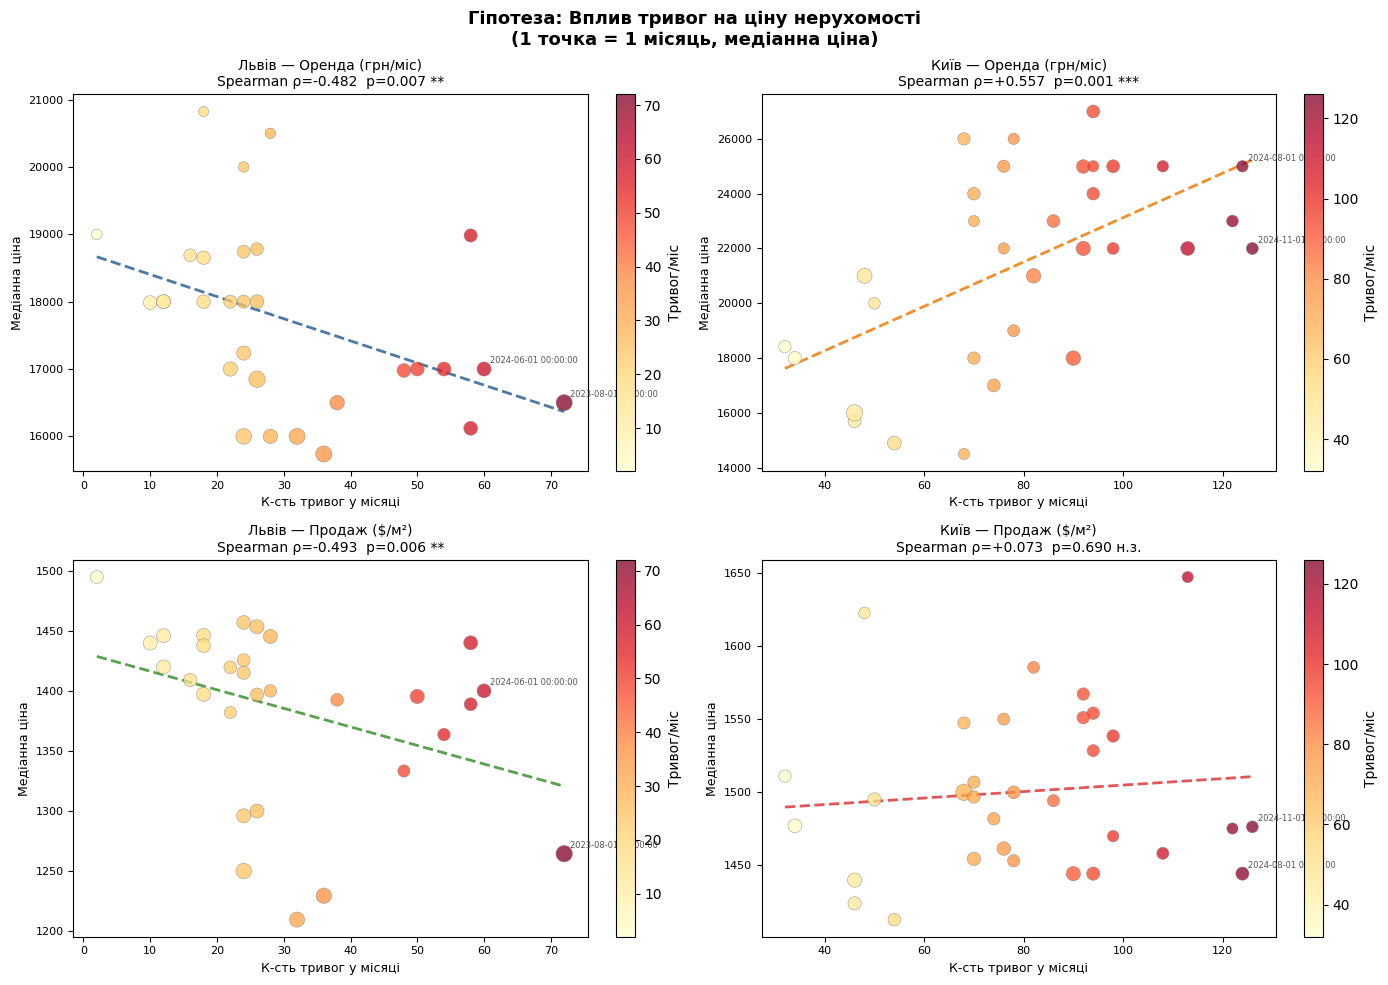


=== Spearman кореляція: к-сть тривог на місяць vs медіанна ціна (агрегація по місяцях) ===
              ρ Spearman  p-value Значущість  Місяців
Сегмент                                              
Львів Оренда      -0.482   0.0070         **       30
Київ Оренда        0.557   0.0009        ***       32
Львів Продаж      -0.493   0.0057         **       30
Київ Продаж        0.073   0.6903       н.з.       32

=== Спірман по всіх alert-фічах (рядок = оголошення) ===

Львів — Оренда (price_uah):
  alert_count_month                   ρ=-0.062  p=0.0000 ***
  alert_duration_h_month              ρ=-0.065  p=0.0000 ***
  alert_days_month                    ρ=-0.064  p=0.0000 ***
  alert_count_cumulative              ρ=+0.136  p=0.0000 ***

Київ — Оренда (price_uah):
  alert_count_month                   ρ=+0.144  p=0.0000 ***
  alert_duration_h_month              ρ=+0.126  p=0.0000 ***
  alert_days_month                    ρ=+0.119  p=0.0000 ***
  alert_count_cumulative              ρ=+0

In [12]:

# ── Hypothesis: Effect of alerts on real estate prices ─────────────────────
# For each segment: aggregate by month (year_month),
# 1 point = 1 month, X = alert count, Y = median price


SEGS_ALERT = [
    ('Львів', 'Оренда',  df_rent_lviv_feat,  'price_uah',    'Львів — Оренда (грн/міс)',  '#4e79a7'),
    ('Київ',  'Оренда',  df_rent_kyiv_feat,  'price_uah',    'Київ — Оренда (грн/міс)',   '#f28e2b'),
    ('Львів', 'Продаж',  df_sale_lviv_feat,  'price_m2_usd', 'Львів — Продаж ($/м²)',     '#59a14f'),
    ('Київ',  'Продаж',  df_sale_kyiv_feat,  'price_m2_usd', 'Київ — Продаж ($/м²)',      '#e15759'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hypothesis: Effect of alerts on real estate prices\n(1 point = 1 month, median price)', 
             fontsize=13, fontweight='bold')

results = []

for ax, (city, ctype, df_seg, price_col, title, color) in zip(axes.flat, SEGS_ALERT):
    df_seg = df_seg.copy()
    df_seg['year_month'] = pd.to_datetime(df_seg['date'], errors='coerce').dt.to_period('M').dt.to_timestamp()
    # Drop obvious price outliers (top 1%)
    df_seg = df_seg.dropna(subset=[price_col, 'alert_count_month', 'year_month'])
    p99 = df_seg[price_col].quantile(0.99)
    df_seg = df_seg[df_seg[price_col] <= p99]

    if len(df_seg) < 10:
        ax.set_title(title)
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)
        continue

    # Aggregate by month: median price + first (identical) alert count
    monthly = (
        df_seg.groupby('year_month')
        .agg(median_price=(price_col, 'median'),
             alert_count=('alert_count_month', 'first'),
             n=('price_uah' if price_col == 'price_uah' else 'price_m2_usd', 'count'))
        .reset_index()
        .sort_values('alert_count')
    )

    if len(monthly) < 5:
        ax.set_title(title)
        ax.text(0.5, 0.5, 'Too few months', ha='center', va='center', transform=ax.transAxes)
        continue

    x = monthly['alert_count'].values
    y = monthly['median_price'].values

    rho, pval = stats.spearmanr(x, y)
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    results.append({'Segment': f'{city} {ctype}', 'ρ Spearman': round(rho, 3),
                    'p-value': round(pval, 4), 'Significance': sig, 'Months': len(monthly)})

    # Scatter: point size ~ ad count
    sizes = (monthly['n'] / monthly['n'].max() * 120 + 20).values
    sc = ax.scatter(x, y, c=monthly['alert_count'].values, cmap='YlOrRd',
                    s=sizes, alpha=0.75, edgecolors='grey', linewidths=0.4, zorder=3)
    plt.colorbar(sc, ax=ax, label='Alerts/mo', fraction=0.04)

    # Trend line
    z = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, np.poly1d(z)(xr), color=color, lw=2, ls='--', label='Trend')

    ax.set_title(f'{title}\nSpearman ρ={rho:+.3f}  p={pval:.3f} {sig}', fontsize=10)
    ax.set_xlabel('Alert count per month', fontsize=9)
    ax.set_ylabel('Median price', fontsize=9)
    ax.tick_params(labelsize=8)

    # Annotate extreme months
    for _, row in monthly.nlargest(2, 'alert_count').iterrows():
        ax.annotate(str(row['year_month']), (row['alert_count'], row['median_price']),
                    textcoords='offset points', xytext=(4, 4), fontsize=6, color='#555')

plt.tight_layout()
plt.show()

# ── Summary correlation table ──────────────────────────────────────────────
print('\n=== Spearman correlation: alerts/month vs median price (monthly aggregation) ===')
if results:
    df_res = pd.DataFrame(results).set_index('Segment')
    print(df_res.to_string())

# ── Extended table: all alert features ────────────────────────────────────
print('\n=== Spearman across all alert features (row = listing) ===')
alert_feats = ['alert_count_month','alert_duration_h_month','alert_days_month','alert_count_cumulative']
for city, ctype, df_seg, price_col, _, _ in SEGS_ALERT:
    sub = df_seg.dropna(subset=[price_col])
    print(f'\n{city} — {ctype} ({price_col}):')
    for feat in alert_feats:
        sub2 = sub.dropna(subset=[feat, price_col])
        if len(sub2) < 30:
            continue
        rho, p = stats.spearmanr(sub2[feat], sub2[price_col])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {feat:<35} ρ={rho:+.3f}  p={p:.4f} {sig}')


### Alert effect on price: time-trend control

The original chart shows a false-positive correlation for Kyiv — both variables (alerts and prices) simply **rise over time** (temporal confounding).
To see the real effect we remove the linear time trend from price and compute the correlation between the **deviation from trend** and the alert count.

| Approach | What we do |
|---|---|
| **Linear detrending** | `actual_price − (a·t + b)` → deviation from time trend |
| **Inflation adjustment** (rent) | `price_UAH / food_price_idx × 100` → real price in Jan-2023 UAH |


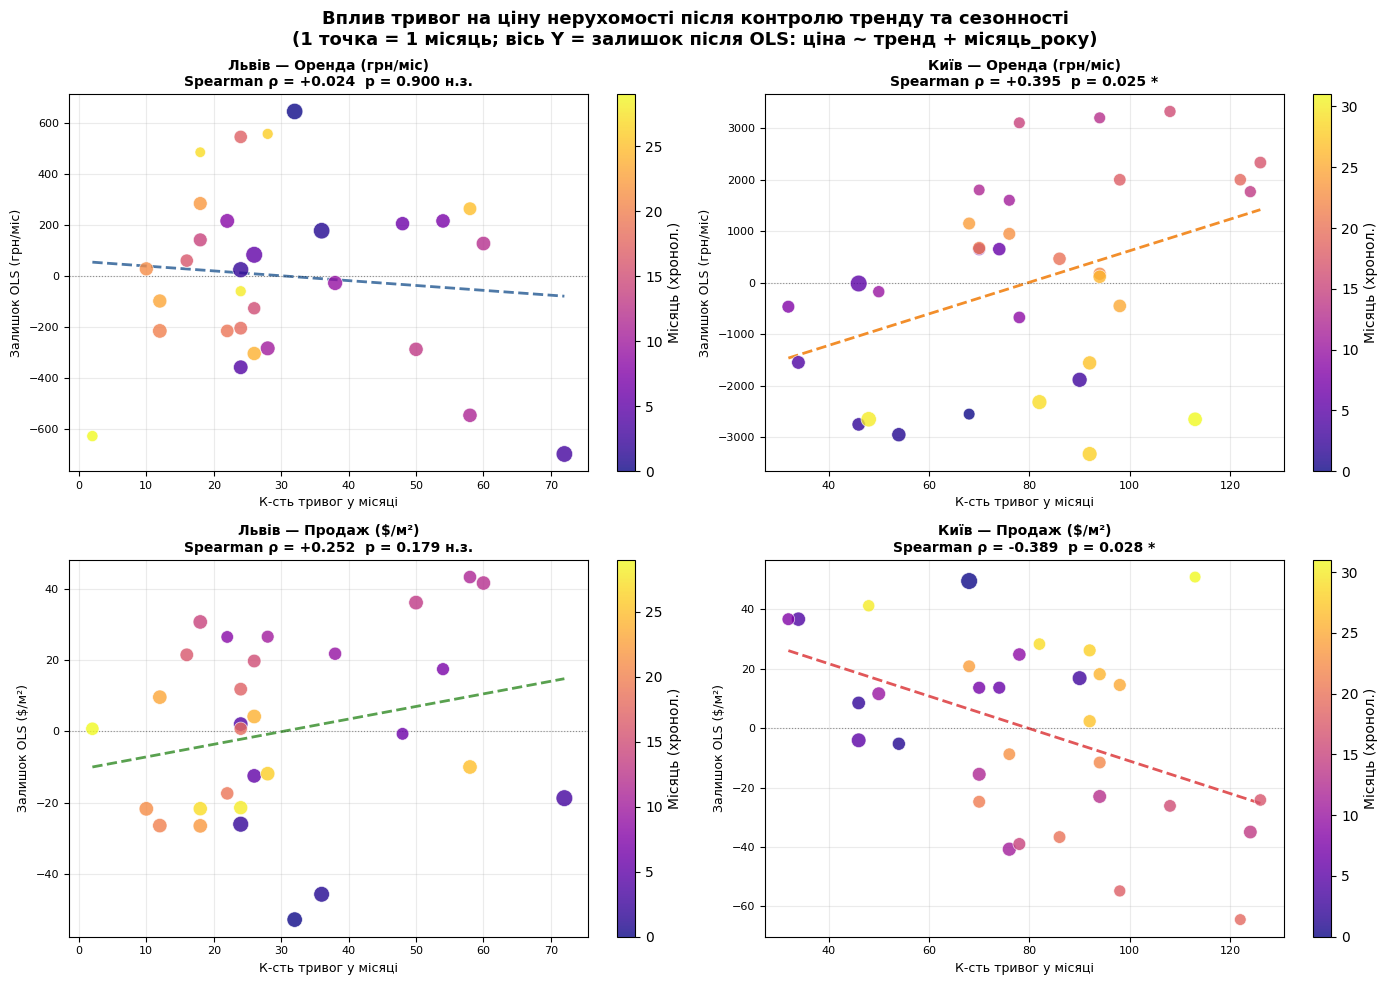


=== Spearman: raw → лін. детрендінг → OLS (тренд + сезон) ===
Сегмент                   ρ raw   ρ лін.    ρ OLS     p OLS   Знач.
Львів — Оренда           -0.482   -0.009   +0.024    0.9003    н.з.
Київ — Оренда            +0.557   +0.375   +0.395    0.0253       *
Львів — Продаж           -0.493   +0.095   +0.252    0.1786    н.з.
Київ — Продаж            +0.073   -0.460   -0.389    0.0277       *

Метод: OLS(ціна ~ t + місяць_1 + ... + місяць_11) → залишки вільні від тренду і сезонності.


In [13]:
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression

_SEGS_ALERT = [
    ('Львів', 'Оренда', df_rent_lviv_feat, 'price_uah',    'грн/міс', '#4e79a7'),
    ('Київ',  'Оренда', df_rent_kyiv_feat,  'price_uah',    'грн/міс', '#f28e2b'),
    ('Львів', 'Продаж', df_sale_lviv_feat,  'price_m2_usd', '$/м²',   '#59a14f'),
    ('Київ',  'Продаж', df_sale_kyiv_feat,  'price_m2_usd', '$/м²',   '#e15759'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Effect of alerts on real estate prices after trend & seasonality control\n'
    '(1 point = 1 month; Y = OLS residual: price ~ trend + month_of_year)',
    fontsize=13, fontweight='bold'
)

detrend_results = []

for ax, (city, ctype, df_seg, price_col, unit, color) in zip(axes.flat, _SEGS_ALERT):
    tmp = df_seg[['date', price_col, 'alert_count_month']].copy()
    tmp['date'] = pd.to_datetime(tmp['date'], errors='coerce')
    tmp[price_col] = pd.to_numeric(tmp[price_col], errors='coerce')
    tmp['alert_count_month'] = pd.to_numeric(tmp['alert_count_month'], errors='coerce')
    tmp = tmp.dropna()
    p99 = tmp[price_col].quantile(0.99)
    tmp = tmp[tmp[price_col] <= p99]

    # ── Monthly aggregation ──────────────────────────────────────────────
    tmp['ym'] = tmp['date'].dt.to_period('M').dt.to_timestamp()
    tmp['month_num'] = tmp['date'].dt.month
    monthly = (
        tmp.groupby('ym')
        .agg(
            price_med=(price_col, 'median'),
            alerts=('alert_count_month', 'first'),
            month_num=('month_num', 'first'),
            n=(price_col, 'count'),
        )
        .reset_index()
        .sort_values('ym')
        .reset_index(drop=True)
    )
    monthly = monthly[monthly['n'] >= 30].copy()
    if len(monthly) < 8:
        ax.set_title(f'{city} — {ctype}\ntoo few months'); continue

    monthly['t'] = np.arange(len(monthly))

    # ── OLS: price ~ linear trend + month dummies (seasonality) ────────
    # Removes both the general upward trend and seasonal peaks/dips
    month_dummies = pd.get_dummies(monthly['month_num'], prefix='m', drop_first=True)
    X_ctrl = pd.concat([monthly[['t']], month_dummies], axis=1).astype(float)
    lr = LinearRegression().fit(X_ctrl, monthly['price_med'])
    monthly['price_dev'] = monthly['price_med'] - lr.predict(X_ctrl)

    # ── Spearman on cleaned residuals ─────────────────────────────────────
    rho, pval = stats.spearmanr(monthly['alerts'], monthly['price_dev'])
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    detrend_results.append({
        'Segment': f'{city} — {ctype}',
        'ρ (OLS-residual)': round(rho, 3),
        'p-value': round(pval, 4),
        'Sig.': sig,
        'Months': len(monthly),
    })

    # ── Scatter ───────────────────────────────────────────────────────────
    sc = ax.scatter(
        monthly['alerts'], monthly['price_dev'],
        c=monthly['t'], cmap='plasma',
        s=(monthly['n'] / monthly['n'].max() * 120 + 25).values,
        alpha=0.8, edgecolors='white', linewidths=0.5, zorder=3,
    )
    plt.colorbar(sc, ax=ax, label='Month (chrono.)', fraction=0.04)

    zf = np.polyfit(monthly['alerts'], monthly['price_dev'], 1)
    xl = np.linspace(monthly['alerts'].min(), monthly['alerts'].max(), 100)
    ax.plot(xl, np.polyval(zf, xl), '--', color=color, lw=2)
    ax.axhline(0, color='black', lw=0.8, alpha=0.4, ls=':')

    ax.set_title(
        f'{city} — {ctype} ({unit})\nSpearman ρ = {rho:+.3f}  p = {pval:.3f} {sig}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Alert count per month', fontsize=9)
    ax.set_ylabel(f'OLS residual ({unit})', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ── Comparison table ───────────────────────────────────────────────────
print('\n=== Spearman: raw → linear detrending → OLS (trend + season) ===')
print(f'{"Segment":<22} {"ρ raw":>8} {"ρ lin.":>8} {"ρ OLS":>8} {"p OLS":>9} {"Sig.":>7}')
raw_rhos    = {'Lviv — Rent': -0.482, 'Kyiv — Rent': +0.557,
               'Lviv — Sale': -0.493, 'Kyiv — Sale': +0.073}
linear_rhos = {'Lviv — Rent': -0.009, 'Kyiv — Rent': +0.375,
               'Lviv — Sale': +0.095, 'Kyiv — Sale': -0.460}
for r in detrend_results:
    seg = r['Segment']
    print(f"{seg:<22} {raw_rhos.get(seg, float('nan')):>+8.3f}"
          f" {linear_rhos.get(seg, float('nan')):>+8.3f}"
          f" {r['ρ (OLS-residual)']:>+8.3f}"
          f" {r['p-value']:>9.4f} {r['Sig.']:>7}")

print('\nMethod: OLS(price ~ t + month_1 + ... + month_11) → residuals free of trend and seasonality.')


## 8. Merging segments → `df_feat`

Before preprocessing, for downstream tasks (correlations, `df_feat`-model, baseline by `segment`), we merge the four datasets into a single `DataFrame` with a **`segment`** column.


In [14]:

# ── Single dataset for analysis / baseline / correlations ─────────────────────
_parts = []
for seg_label, d in [
    ('Lviv — Rent', df_rent_lviv_feat),
    ('Kyiv — Rent',  df_rent_kyiv_feat),
    ('Lviv — Sale', df_sale_lviv_feat),
    ('Kyiv — Sale',  df_sale_kyiv_feat),
]:
    t = d.copy()
    t['segment'] = seg_label
    _parts.append(t)

df_feat = pd.concat(_parts, ignore_index=True)
df_feat['date'] = pd.to_datetime(df_feat['date'], errors='coerce')
print(f"df_feat (before gap-drop): {len(df_feat):,} rows × {df_feat.shape[1]} cols")

# ── Drop gap months (Oct 2024 + Jan 2025) ──────────────────────────────────
_n_before = len(df_feat)
df_feat = drop_gaps(df_feat)
_n_dropped = _n_before - len(df_feat)
print(f"Gap rows dropped:      {_n_dropped:,} ({100*_n_dropped/_n_before:.1f}%)")
print(f"df_feat (after gap):   {len(df_feat):,} rows")

# ── Sanity checks ──────────────────────────────────────────────────────────
_m_tr = split_mask(df_feat, 'train')
_m_va = split_mask(df_feat, 'val')
_m_te = split_mask(df_feat, 'test')
assert (_m_tr & _m_va).sum() == 0, 'train∩val non-empty'
assert (_m_tr & _m_te).sum() == 0, 'train∩test non-empty'
assert (_m_va & _m_te).sum() == 0, 'val∩test non-empty'
_d = pd.to_datetime(df_feat['date'], errors='coerce')
assert not ((_d >= GAP1_START) & (_d <= GAP1_END)).any(), 'GAP1 not cleared'
assert not ((_d >= GAP2_START) & (_d <= GAP2_END)).any(), 'GAP2 not cleared'

print(f"\nSplit sizes:  Train {_m_tr.sum():>7,} | Val {_m_va.sum():>6,} | Test {_m_te.sum():>6,}")
print("Split integrity: OK ✓")
print("\nSegment breakdown:")
print(df_feat['segment'].value_counts().to_string())


df_feat (до gap-drop): 964,732 rows × 101 cols
Gap rows dropped:      56,550 (5.9%)
df_feat (після gap):   908,182 rows

Split sizes:  Train 713,347 | Val 86,076 | Test 108,759
Split integrity: OK ✓

Segment breakdown:
segment
Київ — Продаж     472402
Київ — Оренда     180964
Львів — Продаж    133629
Львів — Оренда    121187


In [15]:
# ── Save feat-segments ─────────────────────────────────────────────────
import pickle
_out = _DATA_DIR / 'feat_segments.pkl'
_feat = {
    ('Львів','Оренда'): df_rent_lviv_feat,
    ('Київ', 'Оренда'): df_rent_kyiv_feat,
    ('Львів','Продаж'): df_sale_lviv_feat,
    ('Київ', 'Продаж'): df_sale_kyiv_feat,
}
with open(_out, 'wb') as f: pickle.dump(_feat, f)
print(f'✅ Saved → {_out}')
for k,v in _feat.items(): print(f'  {k}: {len(v):,} rows, {v.shape[1]} cols')


✅ Збережено → /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package/notebooks/notebooks_data/feat_segments.pkl
  ('Львів', 'Оренда'): 126,946 rows, 100 cols
  ('Київ', 'Оренда'): 193,642 rows, 100 cols
  ('Львів', 'Продаж'): 142,972 rows, 100 cols
  ('Київ', 'Продаж'): 501,172 rows, 100 cols
